# Solar Radiation Data Analysis

This notebook performs exploratory data analysis (EDA) on a solar radiation dataset to investigate patterns between environmental variables such as temperature and solar radiation.

The objective of this analysis is to:

- Explore the dataset structure
- Analyze relationships between temperature and radiation
- Visualize the distribution of solar radiation
- Identify seasonal trends in solar radiation

The dataset used in this project was obtained from Kaggle.

In [2]:
# Import required libraries

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

## Loading the Dataset

The dataset is loaded using the Pandas library.  
We then preview the first few rows to understand the structure of the data.

In [3]:
# Load dataset
data = pd.read_csv("data/SolarPrediction.csv")

# Preview dataset
data.head()

,UNIXTime,Data,Time,Radiation,Temperature,Pressure,Humidity,WindDirection(Degrees),Speed,TimeSunRise,TimeSunSet
0,1475229326,9/29/2016 12:00:00 AM,23:55:26,1.21,48,30.46,59,177.39,5.62,06:13:00,18:13:00
1,1475229023,9/29/2016 12:00:00 AM,23:50:23,1.21,48,30.46,58,176.78,3.37,06:13:00,18:13:00
2,1475228726,9/29/2016 12:00:00 AM,23:45:26,1.23,48,30.46,57,158.75,3.37,06:13:00,18:13:00
3,1475228421,9/29/2016 12:00:00 AM,23:40:21,1.21,48,30.46,60,137.71,3.37,06:13:00,18:13:00
4,1475228124,9/29/2016 12:00:00 AM,23:35:24,1.17,48,30.46,62,104.95,5.62,06:13:00,18:13:00


## Creating Temperature Ranges

To better understand how solar radiation varies with temperature,  
temperature values are grouped into discrete intervals.

These ranges allow us to calculate the **average radiation within each temperature category**.

In [4]:
bins = [0, 10, 20, 30, 40, 50]
labels = ["0-10", "10-20", "20-30", "30-40", "40-50"]

data["TempRange"] = pd.cut(data["Temperature"], bins=bins, labels=labels)

## Average Solar Radiation vs Temperature Range

In this section, we compute the **average solar radiation for each temperature range**.

This helps identify whether higher temperature intervals correspond to higher radiation levels.

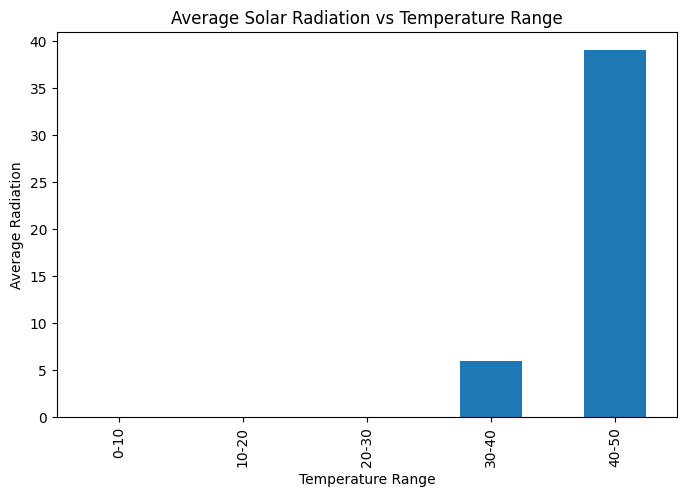

In [5]:
avg_radiation = data.groupby("TempRange", observed=False)["Radiation"].mean()

plt.figure(figsize=(8,5))
avg_radiation.plot(kind="bar")

plt.title("Average Solar Radiation vs Temperature Range")
plt.xlabel("Temperature Range")
plt.ylabel("Average Radiation")

plt.savefig("figures/avg_radiation_temperature.png")
plt.show()

## Distribution of Solar Radiation

A histogram is used to examine the distribution of radiation values in the dataset.

This visualization helps identify:

- The most common radiation levels
- The spread of the data
- Possible outliers

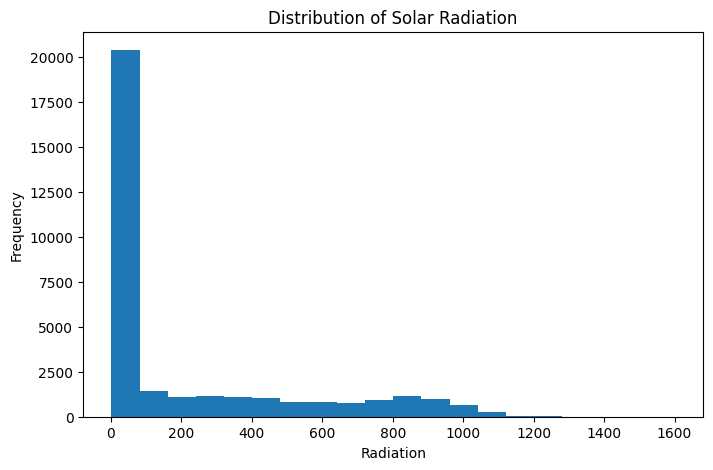

In [6]:
plt.figure(figsize=(8,5))
plt.hist(data["Radiation"], bins=20)

plt.title("Distribution of Solar Radiation")
plt.xlabel("Radiation")
plt.ylabel("Frequency")

plt.savefig("figures/radiation_distribution.png")
plt.show()

## Relationship Between Temperature and Solar Radiation

A scatter plot is used to visualize the relationship between temperature and radiation.

Scatter plots are useful for identifying **correlations between variables**.

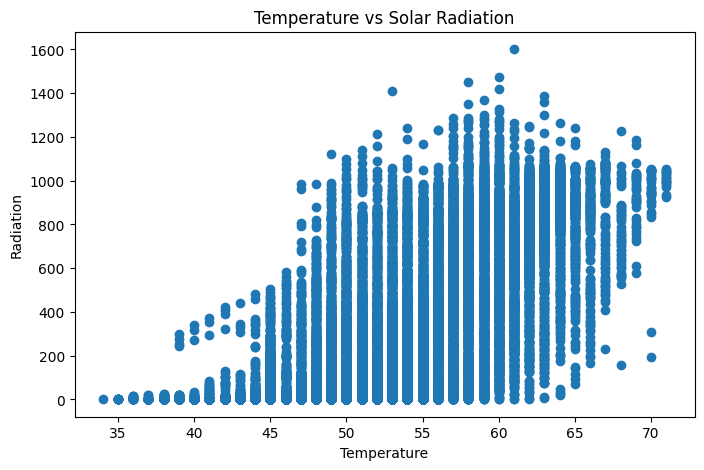

In [7]:
plt.figure(figsize=(8,5))
plt.scatter(data["Temperature"], data["Radiation"])

plt.title("Temperature vs Solar Radiation")
plt.xlabel("Temperature")
plt.ylabel("Radiation")

plt.savefig("figures/temp_vs_radiation.png")
plt.show()

## Monthly Average Solar Radiation

To observe seasonal trends, we convert the date column into a datetime format and extract the month.

We then compute the **average radiation for each month**.

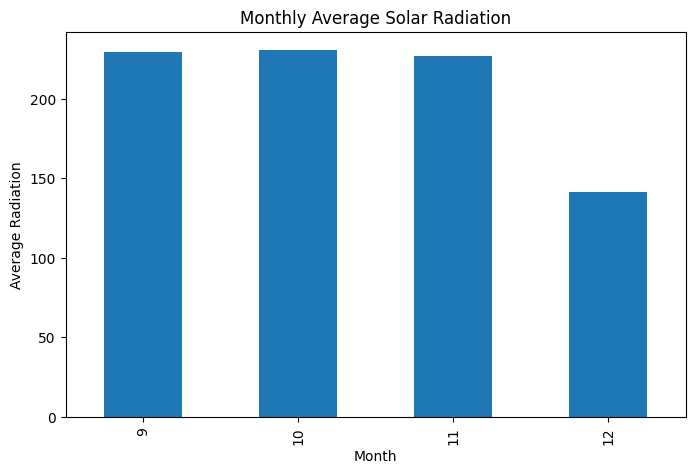

In [10]:
# Convert Data column to datetime
data["Data"] = pd.to_datetime(data["Data"], format='%d-%m-%Y')

# Extract month
data["Month"] = data["Data"].dt.month

# Monthly average radiation
monthly_avg = data.groupby("Month")["Radiation"].mean()

plt.figure(figsize=(8,5))
monthly_avg.plot(kind="bar")

plt.title("Monthly Average Solar Radiation")
plt.xlabel("Month")
plt.ylabel("Average Radiation")

plt.savefig("figures/monthly_radiation.png")
plt.show()

## Conclusion

The exploratory analysis highlights several patterns in the solar radiation dataset:

- Solar radiation tends to increase with higher temperature ranges.
- Radiation values show a moderate distribution with fewer extreme observations.
- Scatter analysis suggests a positive relationship between temperature and radiation.
- Monthly aggregation reveals seasonal variation in solar radiation levels.

This analysis demonstrates fundamental exploratory data analysis techniques using Python.